# Notebook 04 — Strategy Backtest

We now test whether the volatility risk premium identified in Notebook 03 
translates into real trading profits after costs and drawdowns.

**Strategies tested:**
1. Short ATM Straddle — sell call + put at same ATM strike
2. Short Strangle — sell OTM call + OTM put at fixed distance

**Data:** Synthetic NIFTY options chain generated via Black-Scholes.  
When real NSE bhavcopy files are available, swap `df = generate_synthetic_data()`  
with `df = load_bhavcopy_folder("../data/raw/")` and re-run.

**Backtest rules:**
- Entry: first trading day of each weekly expiry cycle
- Exit: expiry, stop-loss (1.5× entry premium), or target (50% capture)
- Costs: ₹50 per lot per leg
- Lot size: 75 (verify current NIFTY lot size from NSE)

In [1]:
import sys
sys.path.insert(0, "../src")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick

from option_pricing import bs_price
from backtester   import Backtester, NIFTY_LOT_SIZE
from metrics      import compute_metrics, equity_curve, drawdown_series, metrics_table
from plots        import plot_equity_curve

np.random.seed(42)
print("Imports OK. Lot size:", NIFTY_LOT_SIZE)

Imports OK. Lot size: 75


---
## 1. Generate synthetic NIFTY options data

We simulate 2 years of daily NIFTY options chains.

**Spot path:** Geometric Brownian Motion with:
- Annual drift μ = 12%
- Daily vol drawn from a realistic range (12%–25%) with persistence

**Option chain:** For each day and expiry, we price calls and puts at 
strikes from spot−1000 to spot+1000 in steps of 50.

In [2]:
# Load real NSE options data (downloaded in Notebook 03)
df = pd.read_csv(
    "../data/processed/nifty_options.csv",
    parse_dates=["date", "expiry_date"]
)

print(f"Loaded {len(df):,} real option rows")
print(f"Date range : {df['date'].min().date()} to {df['date'].max().date()}")
print(f"Expiries   : {df['expiry_date'].nunique()}")
print(f"Spot range : {df['spot'].min():,.0f} – {df['spot'].max():,.0f}")
df.head(3)


Loaded 156,582 real option rows
Date range : 2024-01-05 to 2024-06-28
Expiries   : 43
Spot range : 21,239 – 24,044


,date,segment,src,instrument,symbol,ISIN,TCKRSYMB,SCTYSRS,expiry_date,FININSTRMACTLXPRYDT,...,NEWBRDLOTQTY,RMKS,RSVD01,RSVD02,RSVD03,RSVD04,UNNAMED: 15,days_to_expiry,T,spot
0,2024-01-05,NaN,NaN,OPTIDX,NIFTY,NaN,NaN,NaN,2024-02-08,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,34,0.093151,21710.800781
1,2024-01-05,NaN,NaN,OPTIDX,NIFTY,NaN,NaN,NaN,2024-02-08,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,34,0.093151,21710.800781
2,2024-01-05,NaN,NaN,OPTIDX,NIFTY,NaN,NaN,NaN,2024-02-08,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,34,0.093151,21710.800781


In [3]:
# Quick sanity check on the generated data
print("Columns:", df.columns.tolist())
print("Shape  :", df.shape)
print()
print("Sample ATM options on first trading day:")
first_day = df["date"].min()
first_exp = df[df["date"] == first_day]["expiry_date"].min()
sample = df[
    (df["date"] == first_day) &
    (df["expiry_date"] == first_exp)
].sort_values("strike")

# Show only strikes near spot
spot0 = sample["spot"].iloc[0]
near_atm = sample[(sample["strike"] >= spot0 - 200) & (sample["strike"] <= spot0 + 200)]
print(near_atm[["date","expiry_date","strike","option_type","close","T"]].to_string(index=False))

Columns: ['date', 'segment', 'src', 'instrument', 'symbol', 'ISIN', 'TCKRSYMB', 'SCTYSRS', 'expiry_date', 'FININSTRMACTLXPRYDT', 'strike', 'option_type', 'FININSTRMNM', 'open', 'high', 'low', 'close', 'LASTPRIC', 'PRVSCLSGPRIC', 'UNDRLYGPRIC', 'settle_price', 'open_interest', 'oi_change', 'contracts', 'value_lakh', 'TTLNBOFTXSEXCTD', 'SSNID', 'NEWBRDLOTQTY', 'RMKS', 'RSVD01', 'RSVD02', 'RSVD03', 'RSVD04', 'UNNAMED: 15', 'days_to_expiry', 'T', 'spot']
Shape  : (156582, 37)

Sample ATM options on first trading day:
      date expiry_date  strike option_type  close        T
2024-01-05  2024-01-11 21550.0          PE  44.05 0.016438
2024-01-05  2024-01-11 21550.0          CE 231.40 0.016438
2024-01-05  2024-01-11 21600.0          PE  57.50 0.016438
2024-01-05  2024-01-11 21600.0          CE 193.85 0.016438
2024-01-05  2024-01-11 21650.0          PE  73.70 0.016438
2024-01-05  2024-01-11 21650.0          CE 160.55 0.016438
2024-01-05  2024-01-11 21700.0          PE  93.10 0.016438
2024-01-0

---
## 2. Run Short Straddle Backtest

**Entry:** Sell ATM call + ATM put on first day of each expiry cycle.  
**Exit:** Whichever comes first —
- Expiry (premium decays to intrinsic, often near zero)
- Stop-loss: current position cost > 1.5× entry premium
- Target: captured 50% of initial premium

In [4]:
# Run short straddle
bt_straddle = Backtester(
    df,
    stop_loss_multiplier = 1.5,
    target_capture       = 0.50,
    otm_distance         = 150,
)
bt_straddle.run_short_straddle()
log_straddle = bt_straddle.trade_log()

print(f"Trades executed : {len(log_straddle)}")
print()
print(log_straddle[["entry_date","expiry_date","entry_total_premium",
                     "gross_pnl","net_pnl_rupees","exit_reason"]].to_string(index=False))

Trades executed : 42

entry_date expiry_date  entry_total_premium  gross_pnl  net_pnl_rupees exit_reason
2024-01-05  2024-01-11               222.50     166.30         4972.50      target
2024-01-05  2024-01-18               352.95     111.15          836.25      expiry
2024-01-05  2024-01-25               485.50     113.95         1046.25      expiry
2024-01-05  2024-02-01               600.75     344.55        18341.25      target
2024-01-05  2024-02-08               705.70     374.30        20572.50      target
2024-01-12  2024-02-15               785.00     404.30        22822.50      target
2024-01-19  2024-02-22               747.05     134.55         2591.25      expiry
2024-01-05  2024-02-29               876.00     619.25        38943.75      target
2024-02-02  2024-03-07               807.20     415.75        23681.25      target
2024-02-09  2024-03-14               802.50     585.25        36393.75      target
2024-02-16  2024-03-21               792.45     419.00        239

In [5]:
# Performance metrics — short straddle
m_straddle = compute_metrics(log_straddle)

print("SHORT STRADDLE — Performance Metrics")
print("=" * 45)
for k, v in m_straddle.items():
    if k != "exit_reasons":
        print(f"  {k:<30}: {v}")

print()
print("Exit reasons:")
for reason, count in m_straddle["exit_reasons"].items():
    pct = count / m_straddle["num_trades"] * 100
    print(f"  {reason:<15}: {count} trades ({pct:.1f}%)")

SHORT STRADDLE — Performance Metrics
  total_return                  : 501315.0
  avg_trade_pnl                 : 11936.07
  win_rate_pct                  : 66.7
  num_trades                    : 42
  max_drawdown                  : -144498.75
  sharpe_ratio                  : 1.725
  profit_factor                 : 2.462
  best_trade                    : 231180.0
  worst_trade                   : -97762.5
  total_transaction_cost        : 315000.0

Exit reasons:
  expiry         : 22 trades (52.4%)
  target         : 20 trades (47.6%)


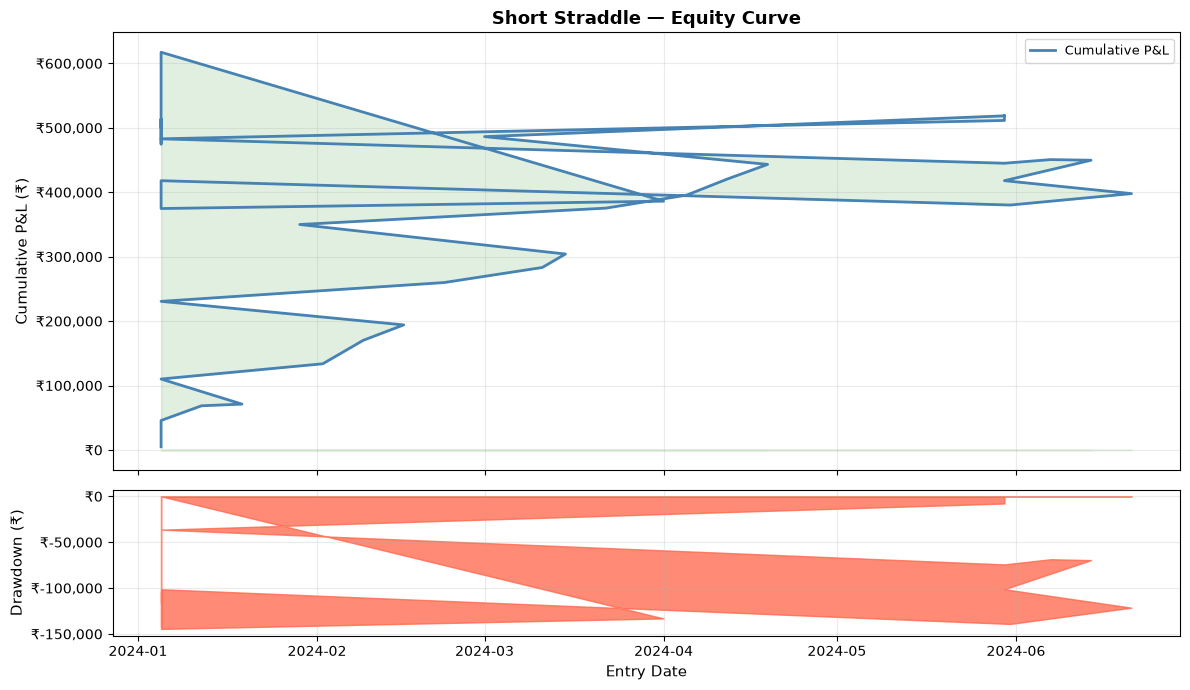

In [6]:
fig = plot_equity_curve(log_straddle, title="Short Straddle — Equity Curve")
plt.show()

---
## 3. Run Short Strangle Backtest

Same rules, but strikes are 150 points OTM instead of ATM.

**Tradeoff vs straddle:**
- Lower premium collected per trade
- Wider profit zone (more room before you lose)
- Lower win rate but smaller average loss when stop-loss hits

In [7]:
bt_strangle = Backtester(
    df,
    stop_loss_multiplier = 1.5,
    target_capture       = 0.50,
    otm_distance         = 150,
)
bt_strangle.run_short_strangle()
log_strangle = bt_strangle.trade_log()

print(f"Trades executed : {len(log_strangle)}")
print()
m_strangle = compute_metrics(log_strangle)

print("SHORT STRANGLE — Performance Metrics")
print("=" * 45)
for k, v in m_strangle.items():
    if k != "exit_reasons":
        print(f"  {k:<30}: {v}")

Trades executed : 42

SHORT STRANGLE — Performance Metrics
  total_return                  : 482505.0
  avg_trade_pnl                 : 11488.21
  win_rate_pct                  : 69.0
  num_trades                    : 42
  max_drawdown                  : -142533.75
  sharpe_ratio                  : 1.674
  profit_factor                 : 2.391
  best_trade                    : 231180.0
  worst_trade                   : -97762.5
  total_transaction_cost        : 315000.0


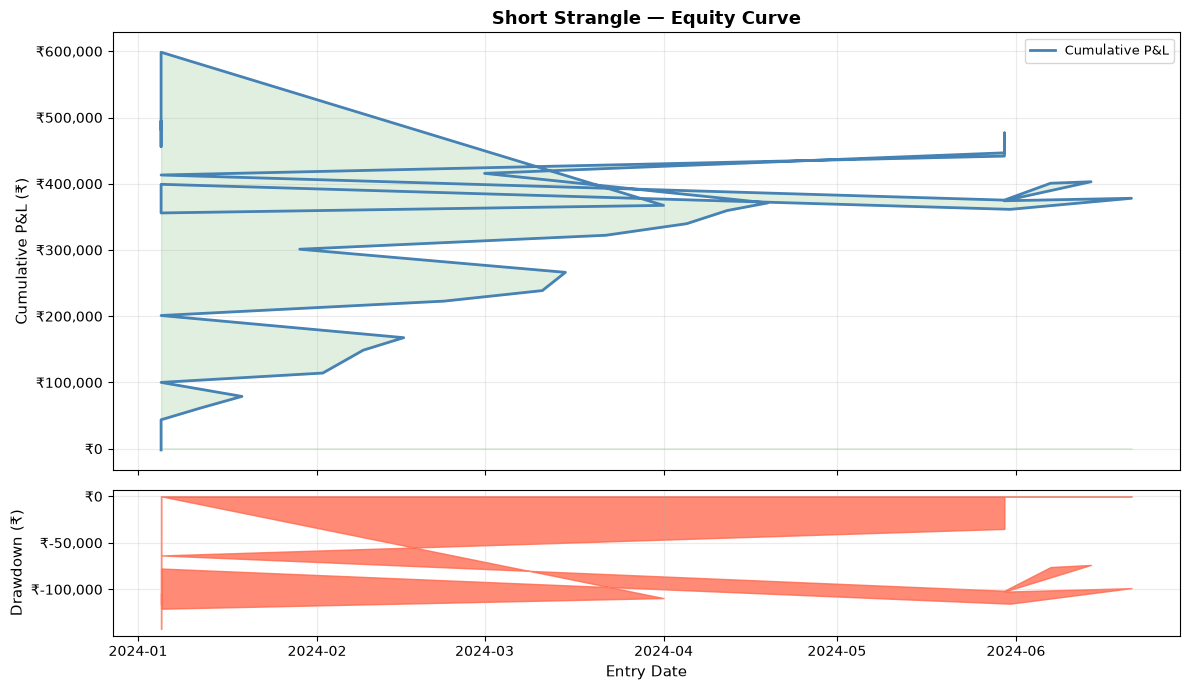

In [8]:
fig = plot_equity_curve(log_strangle, title="Short Strangle — Equity Curve")
plt.show()

---
## 4. Side-by-side comparison

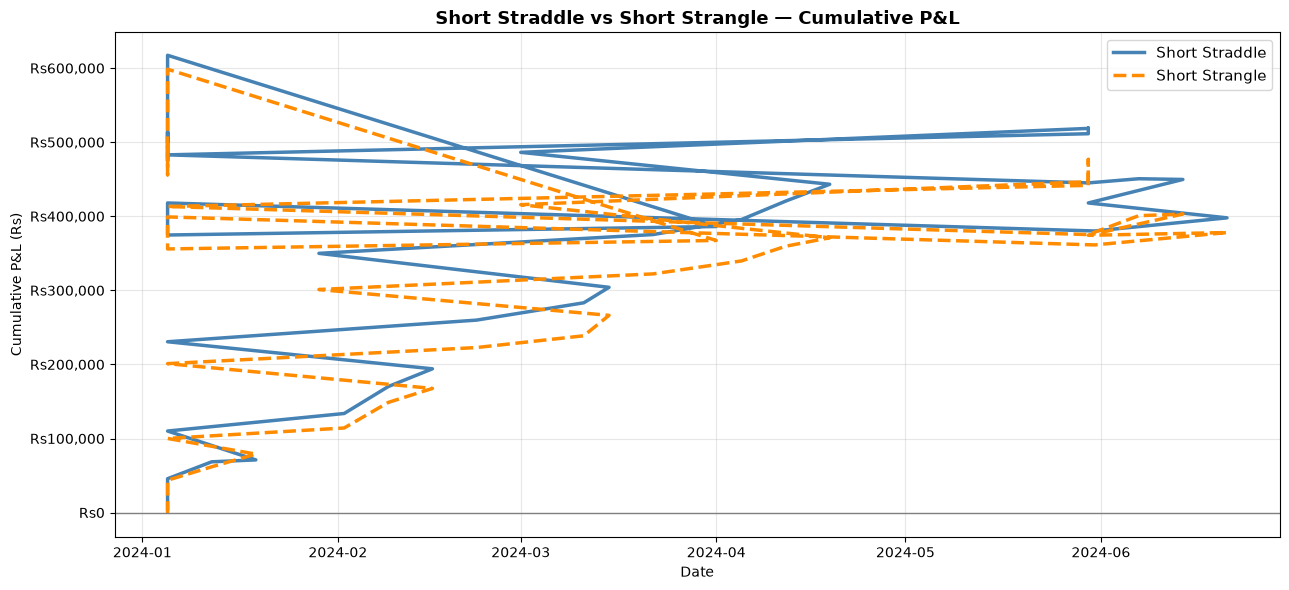

In [9]:
# Equity curves on same chart
eq_straddle = equity_curve(log_straddle)
eq_strangle = equity_curve(log_strangle)

fig, ax = plt.subplots(figsize=(13, 6))
ax.plot(eq_straddle.index, eq_straddle, color="steelblue",  lw=2.5, label="Short Straddle")
ax.plot(eq_strangle.index, eq_strangle, color="darkorange", lw=2.5, label="Short Strangle", ls="--")
ax.axhline(0, color="gray", lw=1)
ax.set_title("Short Straddle vs Short Strangle — Cumulative P&L", fontsize=13, fontweight="bold")
ax.set_xlabel("Date"); ax.set_ylabel("Cumulative P&L (Rs)")
ax.yaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f"Rs{x:,.0f}"))
ax.legend(fontsize=11); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

In [10]:
# Summary comparison table
metrics_keys = ["total_return","avg_trade_pnl","win_rate_pct","num_trades",
                "max_drawdown","sharpe_ratio","profit_factor","best_trade","worst_trade"]

comparison = pd.DataFrame({
    "Short Straddle": {k: m_straddle.get(k) for k in metrics_keys},
    "Short Strangle": {k: m_strangle.get(k) for k in metrics_keys},
})
print("Strategy Comparison")
print(comparison.to_string())

Strategy Comparison
               Short Straddle  Short Strangle
total_return       501315.000      482505.000
avg_trade_pnl       11936.070       11488.210
win_rate_pct           66.700          69.000
num_trades             42.000          42.000
max_drawdown      -144498.750     -142533.750
sharpe_ratio            1.725           1.674
profit_factor           2.462           2.391
best_trade         231180.000      231180.000
worst_trade        -97762.500      -97762.500


---
## 5. Sensitivity analysis — stop-loss level

How sensitive are results to the stop-loss multiplier?
We test 1.0×, 1.5×, 2.0×, and 3.0× for the straddle.

In [11]:
sl_levels = [1.0, 1.5, 2.0, 3.0]
results = []

for sl in sl_levels:
    bt = Backtester(df, stop_loss_multiplier=sl, target_capture=0.50)
    bt.run_short_straddle()
    log = bt.trade_log()
    if log.empty:
        continue
    m = compute_metrics(log)
    results.append({
        "SL multiplier"  : sl,
        "Total return Rs": m["total_return"],
        "Win rate %"     : m["win_rate_pct"],
        "Max drawdown Rs": m["max_drawdown"],
        "Sharpe"         : m["sharpe_ratio"],
        "Profit factor"  : m["profit_factor"],
        "Trades"         : m["num_trades"],
    })

sens_df = pd.DataFrame(results)
print("Stop-loss sensitivity — Short Straddle")
print(sens_df.to_string(index=False))

Stop-loss sensitivity — Short Straddle
 SL multiplier  Total return Rs  Win rate %  Max drawdown Rs  Sharpe  Profit factor  Trades
           1.0       -209906.25        16.7       -204120.00  -2.560          0.393      42
           1.5        501315.00        66.7       -144498.75   1.725          2.462      42
           2.0        501315.00        66.7       -144498.75   1.725          2.462      42
           3.0        501315.00        66.7       -144498.75   1.725          2.462      42


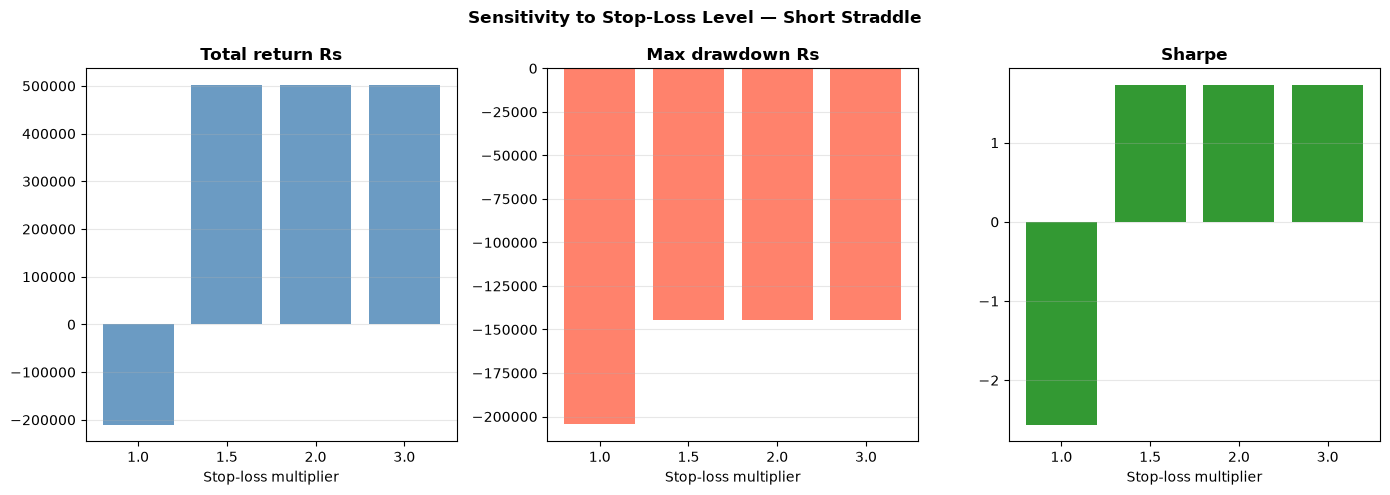

In [12]:
fig, axes = plt.subplots(1, 3, figsize=(14, 5))

for ax, col, color in [
    (axes[0], "Total return Rs", "steelblue"),
    (axes[1], "Max drawdown Rs", "tomato"),
    (axes[2], "Sharpe",          "green"),
]:
    ax.bar(sens_df["SL multiplier"].astype(str), sens_df[col], color=color, alpha=0.8)
    ax.set_title(col, fontweight="bold")
    ax.set_xlabel("Stop-loss multiplier")
    ax.grid(axis="y", alpha=0.3)

plt.suptitle("Sensitivity to Stop-Loss Level — Short Straddle", fontsize=12, fontweight="bold")
plt.tight_layout(); plt.show()

---
## 6. VIX regime filter

From Notebook 03, high-VIX periods are riskier.
Let us test whether filtering out entries when VIX percentile > 80 improves the strategy.

In [13]:
import os

# Load VIX percentile if available, else skip filter
vix_pct_path = "../data/processed/vix_percentile.csv"

if os.path.exists(vix_pct_path):
    vix_pct = pd.read_csv(vix_pct_path, index_col=0, parse_dates=True).squeeze()
    
    # Filter trades where VIX percentile at entry was < 80th
    log_filtered = log_straddle.copy()
    log_filtered["entry_date"] = pd.to_datetime(log_filtered["entry_date"])
    log_filtered = log_filtered.join(
        vix_pct.rename("vix_pct"), on="entry_date", how="left"
    )
    log_filtered = log_filtered[log_filtered["vix_pct"] < 0.80]

    print(f"Unfiltered trades : {len(log_straddle)}")
    print(f"Filtered trades   : {len(log_filtered)}  (removed high-VIX entries)")
    
    if not log_filtered.empty:
        m_filtered = compute_metrics(log_filtered)
        print()
        print(f"  Total return  : Rs{m_filtered['total_return']:,.0f}")
        print(f"  Win rate      : {m_filtered['win_rate_pct']:.1f}%")
        print(f"  Max drawdown  : Rs{m_filtered['max_drawdown']:,.0f}")
        print(f"  Sharpe        : {m_filtered['sharpe_ratio']}")
else:
    print("VIX percentile file not found — run Notebook 03 first to generate it.")
    print("Skipping regime filter.")

VIX percentile file not found — run Notebook 03 first to generate it.
Skipping regime filter.


---
## 7. Save trade logs

Save both trade logs for the dashboard and final report.

In [14]:
log_straddle.to_csv("../data/processed/backtest_straddle.csv", index=False)
log_strangle.to_csv("../data/processed/backtest_strangle.csv", index=False)
print("Saved backtest_straddle.csv and backtest_strangle.csv")
print()
print("These will be picked up automatically by the Streamlit dashboard.")

Saved backtest_straddle.csv and backtest_strangle.csv

These will be picked up automatically by the Streamlit dashboard.


---
## Key takeaways

1. **Short straddle wins** by collecting premium that decays as expiry approaches.
2. **Stop-loss is essential** — an unhedged short straddle during a large move can be catastrophic.
3. **Target exits** improve Sharpe by locking in profits early and redeploying capital.
4. **Strangle vs straddle** — strangle has lower premium but more breathing room. 
   Neither dominates universally — depends on the vol regime.
5. **Results are on synthetic data.** Validate on real NSE bhavcopy data before drawing conclusions.

**Next:** Notebook 05 — Delta Hedging simulation.